## Ankle RSU series - mechanism

In [1]:
import numpy as np
import kinematics_utils as ku

In [2]:

l_fixed = 10.0
lbar = 75.0    
lrod1 = 246.65
lrod2 = 148.21     
lspacing_1 = 60.0  
lspacing_2 = 60.0

O = np.array([0.0, 0.0, 0.0])
rA1 = np.array([ lspacing_1/2.0, l_fixed, 260.0])
rA2 = np.array([-lspacing_1/2.0, l_fixed, 160.0])
rB1_H = np.array([ lspacing_2/2.0, 80.48, 234.35])
rB2_H = np.array([-lspacing_2/2.0, 80.48, 134.35])
rC1_H = np.array([ lspacing_2/2.0, 46.89, -l_fixed])
rC2_H = np.array([-lspacing_2/2.0, 46.89, -l_fixed])
rD1_H = np.array([ lspacing_1/2.0, -100.0, -l_fixed])
rD2_H = np.array([-lspacing_1/2.0, -100.0, -l_fixed])
S1 = np.array([-lspacing_1/2.0, 10.0, 260.0])
S2 = np.array([ -lspacing_1/2.0, 0.0, 0.0])
S3 = np.array([ lspacing_1/2.0, l_fixed, 160.0])
S4 = np.array([  lspacing_1/2.0, 0.0, 0.0])

axis = np.array([1.0, 0.0, 0.0])

In [3]:
point_style_ = {
    "O": "r",
    "A1": "r",
    "A2": "r",
    "B1": "b",
    "B2": "b",
    "C1": "b",
    "C2": "b",
    "D1": "b",
    "D2": "b",
    "B1H": "r",
    "B2H": "r",
    "C1H": "r",
    "C2H": "r",
    "D1H": "r",
    "D2H": "r",
}

links_ = [
    ("A1", "B1"),
    ("A2", "B2"),
    ("B1", "C1"),
    ("B2", "C2"),
    ("C1", "C2"),
    ("C1", "D1"),
    ("C2", "D2"),
    ("D1", "D2"),
]

fixed_ = [
    ("S1", "S2"),
    ("S2", "S4"),
    ("S4", "A1"),
    ("A1", "S1"),
]

home_ = [("A1","B1H"),
         ("A2","B2H"),
        ("B1H","C1H"),
        ("B2H","C2H"),
        ("C1H","C2H"),
        ("C1H","D1H"),
        ("C2H","D2H"),
        ("D1H","D2H")]

planes_ = [
    {
        "points": ("S1", "S2", "S4", "A1"),
        "color": "cyan",
        "alpha": 0.5,
        "views": ("ax1", "ax2"),
    },
    {
        "points": ("D1", "C1", "C2", "D2"),
        "color": "yellow",
        "alpha": 0.5,
        "views": ("ax1", "ax2"),
    },
]

In [4]:
def solve_and_plot(pitch_deg, roll_deg):

    pitch = np.deg2rad(pitch_deg)
    roll = np.deg2rad(roll_deg)

    R = ku.Rx(pitch) @ ku.Ry(roll)

    # Rotated points
    rC1 = R @ rC1_H
    rC2 = R @ rC2_H
    rD1 = R @ rD1_H
    rD2 = R @ rD2_H

    # Rotation axis
    axis1 = S1 - rA1
    axis1 /= np.linalg.norm(axis1)
    axis2 = rA2 - S3
    axis2 /= np.linalg.norm(axis2)

    # IK
    theta1_candidates = ku.solve_theta(rC1, rA1, rB1_H, lrod1, axis)
    theta2_candidates = ku.solve_theta(rC2, rA2, rB2_H, lrod2, axis)

    if not theta1_candidates or not theta2_candidates:
        print("❌ No IK solution")
        return

    theta1 = theta1_candidates[0]
    theta2 = theta2_candidates[0]

    rB1 = rA1 + ku.rot_axis(axis, theta1) @ (rB1_H - rA1)
    rB2 = rA2 + ku.rot_axis(axis, theta2) @ (rB2_H - rA2)

    print(f"Roll = {roll_deg}°Pitch = {pitch_deg}°, \n")
    print(f"θ1 = {np.degrees(theta1):.6f}°")
    print(f"θ2 = {np.degrees(theta2):.6f}°")

    # print("\nGeometry check:")
    # print(f"Lowerlink1: {np.linalg.norm(rC1 - rB1):.3f} ({lrod1})")
    # print(f"Lowerlink2: {np.linalg.norm(rC2 - rB2):.3f} ({lrod2})")
    # print(f"Upperlink1: {np.linalg.norm(rA1 - rB1):.3f} ({lbar})")
    # print(f"Upperlink2: {np.linalg.norm(rA2 - rB2):.3f} ({lbar})")
    
    points = {
        "O":O,"A1":rA1,"A2":rA2,"B1":rB1,"B2":rB2,
        "C1":rC1,"C2":rC2,"D1":rD1,"D2":rD2,
        "B1H":rB1_H,"B2H":rB2_H,
        "C1H":rC1_H,"C2H":rC2_H,
        "D1H":rD1_H,"D2H":rD2_H,
        "S1":S1,"S2":S2,"S4":S4
    }

    ku.visualize_mechanism(points, point_style_, links_, fixed_, home_, planes_)
    


Roll = -30°Pitch = 0°, 

θ1 = 12.433685°
θ2 = -10.726348°


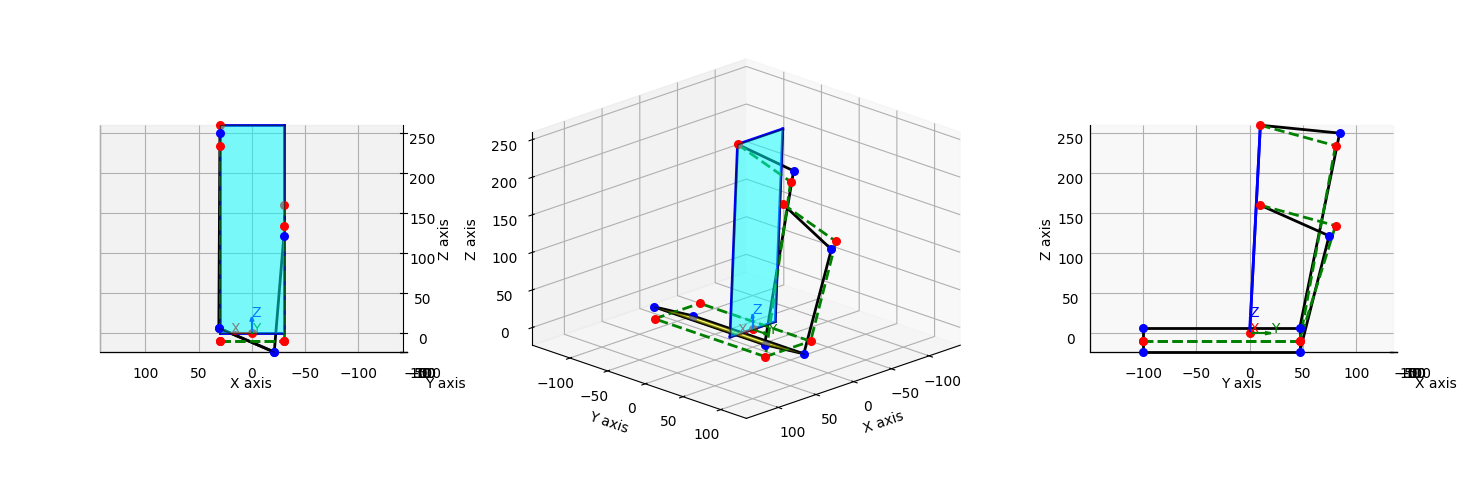

In [ ]:
solve_and_plot(
    pitch_deg = 0,
    roll_deg  = -30,
)